# 📱 Mobile Phone Price Analysis - Final Version

**Author:** [Your Name]  
**Date:** December 2025  
**Dataset:** 379 mobile phones with specifications and prices

## 📋 Analysis Overview

This notebook analyzes mobile phone pricing using:
- **Exploratory Data Analysis (EDA)**
- **OLS Regression** with brand effects
- **Correspondence Analysis** (Brand vs Price Category)
- **Outlier Detection** (Isolation Forest)
- **Value-for-Money Analysis**

---

## 📚 Section 1: Imports and Setup

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Statistical modeling
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats
from scipy.stats import chi2_contingency, jarque_bera

# Machine learning
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import IsolationForest

# Correspondence analysis (optional)
try:
    import prince
    PRINCE_AVAILABLE = True
except ImportError:
    PRINCE_AVAILABLE = False
    print("⚠️ Warning: 'prince' library not available. Install with: pip install prince")

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📊 Section 2: Data Loading and Initial Exploration

In [2]:
# Load the dataset
data = pd.read_csv("./data/cleaned/clean_mobile_data.csv")

print(f"✅ Loaded {len(data)} mobile phones")
print(f"✅ Features: {data.shape[1]} columns")

✅ Loaded 379 mobile phones
✅ Features: 15 columns


In [3]:
# Display first few rows
data.head()

,Brand,Model,Storage,RAM,Screen Size,Camera,Battery Capacity,Price,Camera_TotalMP,Camera_Count,Has_3D,Has_ToF,Price_per_MP,Main_Camera_MP,Camera_clean
0,Apple,iPhone 13 Pro,128,6,6.1,12 + 12 + 12,3095,999.0,36.0,3,False,False,27.750000,12.0,12 + 12 + 12
1,Samsung,Galaxy S21 Ultra,256,12,6.8,108 + 10 + 10 + 12,5000,1199.0,140.0,4,False,False,8.564286,108.0,108 + 10 + 10 + 12
2,OnePlus,9 Pro,128,8,6.7,48 + 50 + 8 + 2,4500,899.0,108.0,4,False,False,8.324074,48.0,48 + 50 + 8 + 2
3,Xiaomi,Redmi Note 10 Pro,128,6,6.67,64 + 8 + 5 + 2,5020,279.0,79.0,4,False,False,3.531646,64.0,64 + 8 + 5 + 2
4,Google,Pixel 6,128,8,6.4,50 + 12.2,4614,799.0,62.2,2,False,False,12.845659,50.0,50 + 12.2


In [4]:
# Dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             379 non-null    object 
 1   Model             379 non-null    object 
 2   Storage           379 non-null    int64  
 3   RAM               379 non-null    int64  
 4   Screen Size       379 non-null    object 
 5   Camera            379 non-null    object 
 6   Battery Capacity  379 non-null    int64  
 7   Price             379 non-null    float64
 8   Camera_TotalMP    379 non-null    float64
 9   Camera_Count      379 non-null    int64  
 10  Has_3D            379 non-null    bool   
 11  Has_ToF           379 non-null    bool   
 12  Price_per_MP      379 non-null    float64
 13  Main_Camera_MP    379 non-null    float64
 14  Camera_clean      379 non-null    object 
dtypes: bool(2), float64(4), int64(4), object(5)
memory usage: 39.4+ KB


In [5]:
# Summary statistics
data.describe()

,Storage,RAM,Battery Capacity,Price,Camera_TotalMP,Camera_Count,Price_per_MP,Main_Camera_MP
count,379.000000,379.000000,379.000000,379.000000,379.00000,379.000000,379.000000,379.000000
mean,124.875989,5.894459,4696.108179,411.509235,57.81029,3.155673,8.896961,43.735092
std,66.151925,2.464445,776.016539,305.958269,31.00466,0.759099,8.202365,24.689186
min,32.000000,2.000000,1821.000000,99.000000,8.00000,1.000000,1.903846,8.000000
25%,64.000000,4.000000,4300.000000,199.000000,28.20000,3.000000,4.150000,13.000000
50%,128.000000,6.000000,5000.000000,299.000000,60.00000,3.000000,5.750000,48.000000
75%,128.000000,8.000000,5000.000000,499.000000,76.00000,4.000000,9.933333,64.000000
max,512.000000,16.000000,7000.000000,1999.000000,171.00000,4.000000,55.527778,108.000000


## 🔧 Section 3: Data Preprocessing

In [6]:
# Convert Screen Size to numeric if needed
if data['Screen Size'].dtype == 'object':
    data['Screen_Size_numeric'] = pd.to_numeric(data['Screen Size'], errors='coerce')
    print("✅ Converted Screen Size to numeric")
else:
    data['Screen_Size_numeric'] = data['Screen Size']

# Create derived features
data['Price_per_RAM'] = data['Price'] / data['RAM']
data['Price_per_Storage'] = data['Price'] / data['Storage']

print("✅ Created derived features")

# Check for missing values
missing = data.isnull().sum()
if missing.sum() > 0:
    print(f"\n⚠️ Missing values found:")
    print(missing[missing > 0])
else:
    print("✅ No missing values")

✅ Converted Screen Size to numeric
✅ Created derived features

⚠️ Missing values found:
Screen_Size_numeric    2
dtype: int64


## 📈 Section 4: Exploratory Data Analysis (EDA)

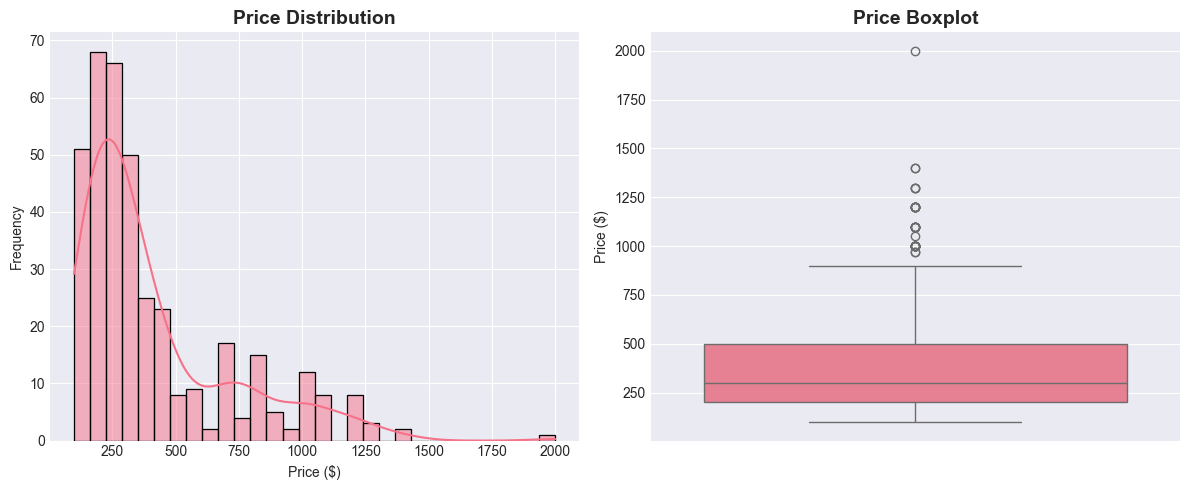

In [7]:
# Price distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data['Price'], bins=30, kde=True)
plt.title('Price Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=data['Price'])
plt.title('Price Boxplot', fontsize=14, fontweight='bold')
plt.ylabel('Price ($)')

plt.tight_layout()
plt.show()

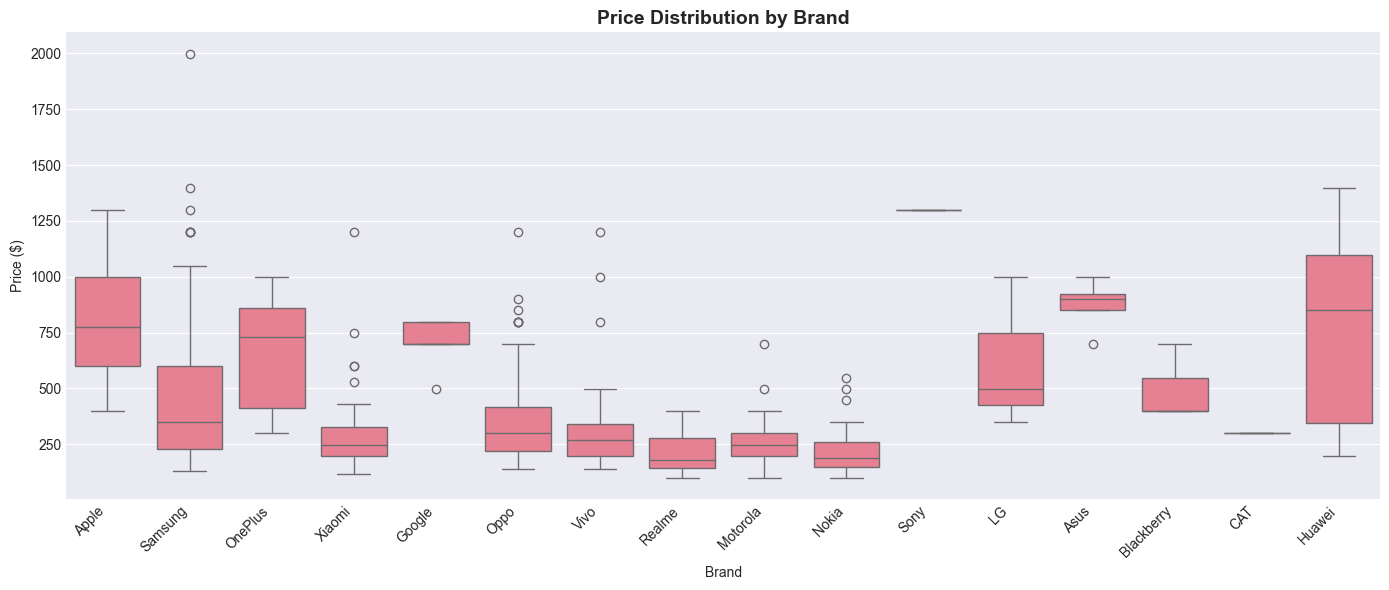

In [8]:
# Price by brand
plt.figure(figsize=(14, 6))
sns.boxplot(x='Brand', y='Price', data=data)
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution by Brand', fontsize=14, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

In [9]:
# Average price by brand
brand_avg = data.groupby("Brand")["Price"].mean().sort_values(ascending=False)
print("Average Price by Brand:")
print(brand_avg)

Average Price by Brand:
Brand
Sony          1299.000000
Asus           874.000000
Apple          783.615385
Huawei         783.166667
Google         699.000000
OnePlus        669.000000
LG             615.666667
Blackberry     499.000000
Samsung        486.547945
Oppo           381.452830
Vivo           333.545455
CAT            299.000000
Xiaomi         285.935484
Motorola       272.636364
Nokia          230.250000
Realme         206.906977
Name: Price, dtype: float64


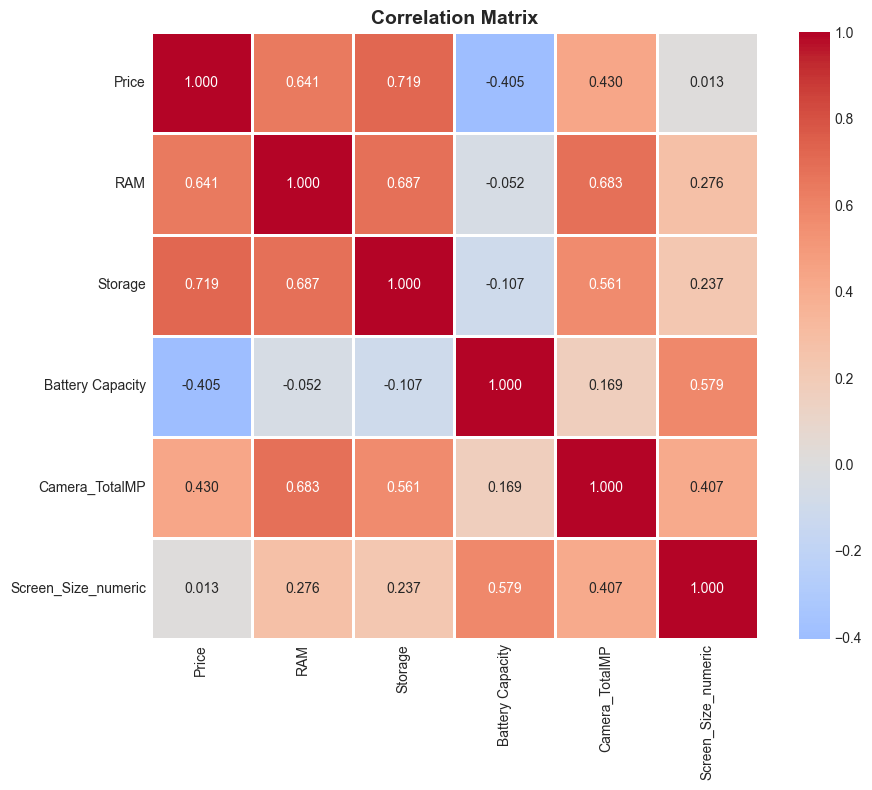


Correlation with Price:
Price                  1.000000
Storage                0.718916
RAM                    0.640511
Camera_TotalMP         0.430230
Screen_Size_numeric    0.013428
Battery Capacity      -0.404610
Name: Price, dtype: float64


In [10]:
# Correlation matrix
numeric_cols = ['Price', 'RAM', 'Storage', 'Battery Capacity', 
                'Camera_TotalMP', 'Screen_Size_numeric']
corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.3f')
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Price:")
print(corr_matrix['Price'].sort_values(ascending=False))

## 🔍 Section 5: Brand-Specific Effects

In [11]:
# RAM price effect by brand
ram_effect = {}

for brand, dfb in data.groupby("Brand"):
    if len(dfb) > 2:  # Need at least 3 points for regression
        model_ram = LinearRegression()
        X = dfb[['RAM']]
        y = dfb['Price']
        model_ram.fit(X, y)
        ram_effect[brand] = model_ram.coef_[0]

ram_effect_df = (
    pd.Series(ram_effect, name='Price_per_GB_RAM')
      .reset_index()
      .rename(columns={'index': 'Brand'})
      .sort_values('Price_per_GB_RAM', ascending=False)
)

print("RAM Price Effect by Brand:")
print(ram_effect_df)

RAM Price Effect by Brand:
         Brand  Price_per_GB_RAM
5           LG        287.500000
0        Apple        168.093923
4       Huawei        155.750000
11     Samsung        125.446056
1         Asus        116.666667
13      Xiaomi         88.671321
8      OnePlus         88.472222
12        Vivo         78.265241
9         Oppo         75.090498
2   Blackberry         75.000000
7        Nokia         74.587156
6     Motorola         59.096774
3       Google         41.666667
10      Realme         36.207622


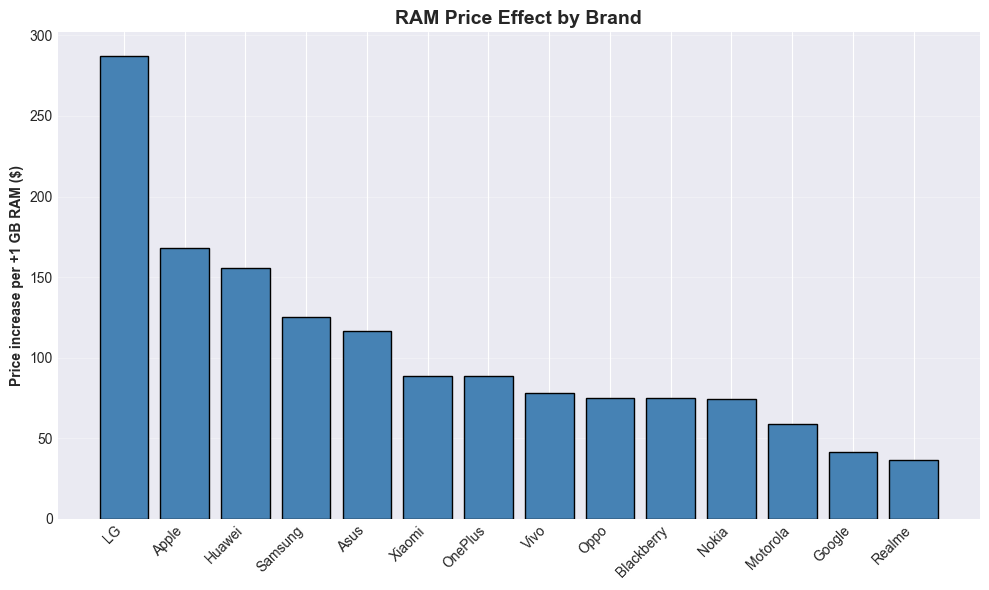

In [12]:
# Plot RAM effect
plt.figure(figsize=(10, 6))
plt.bar(ram_effect_df['Brand'], ram_effect_df['Price_per_GB_RAM'], 
        color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Price increase per +1 GB RAM ($)', fontweight='bold')
plt.title('RAM Price Effect by Brand', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Storage price effect by brand
storage_effect = {}

for brand, dfb in data.groupby("Brand"):
    if len(dfb) > 2:
        model_storage = LinearRegression()
        X = dfb[['Storage']]
        y = dfb['Price']
        model_storage.fit(X, y)
        storage_effect[brand] = model_storage.coef_[0]

storage_effect_df = (
    pd.Series(storage_effect, name='Price_per_GB_Storage')
      .reset_index()
      .rename(columns={'index': 'Brand'})
      .sort_values('Price_per_GB_Storage', ascending=False)
)

print("Storage Price Effect by Brand:")
print(storage_effect_df)

Storage Price Effect by Brand:
         Brand  Price_per_GB_Storage
5           LG              4.492187
11     Samsung              4.040839
12        Vivo              3.831564
9         Oppo              3.512380
13      Xiaomi              3.163524
4       Huawei              2.992029
7        Nokia              2.583786
8      OnePlus              2.527778
6     Motorola              2.176782
10      Realme              1.620543
0        Apple              1.542920
1         Asus              0.260417
2   Blackberry              0.000000
3       Google              0.000000


## 📊 Section 6: OLS Regression Analysis

### ⚠️ FIXED VERSION - Properly defines X_clean and y_clean

In [14]:
# Prepare features for OLS regression
print("Preparing OLS regression model...")

# Select hardware features
features = ['RAM', 'Storage', 'Battery Capacity', 'Camera_TotalMP']
X = data[features].copy()

# Create brand dummy variables (Apple will be reference category)
brand_dummies = pd.get_dummies(data['Brand'], prefix='Brand', drop_first=True)
X = pd.concat([X, brand_dummies], axis=1)

# Add constant term for intercept
X = sm.add_constant(X)

# Target variable
y = data['Price']

# Clean data (remove missing values)
mask = ~(X.isna().any(axis=1) | y.isna())
X_clean = X[mask].astype(float)
y_clean = y[mask]

print(f"✅ Data prepared:")
print(f"   - Observations: {len(X_clean)}")
print(f"   - Features: {X_clean.shape[1]} (including constant)")
print(f"   - Reference Brand: Apple")

Preparing OLS regression model...
✅ Data prepared:
   - Observations: 379
   - Features: 20 (including constant)
   - Reference Brand: Apple


In [15]:
# Fit OLS model
print("Fitting OLS model...")
model = sm.OLS(y_clean, X_clean).fit()

# Display results
print("\n" + "="*80)
print("OLS REGRESSION RESULTS")
print("="*80)
print(model.summary())

Fitting OLS model...

OLS REGRESSION RESULTS
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     83.63
Date:                Wed, 10 Dec 2025   Prob (F-statistic):          3.92e-119
Time:                        14:25:02   Log-Likelihood:                -2386.0
No. Observations:                 379   AIC:                             4812.
Df Residuals:                     359   BIC:                             4891.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [16]:
# Interpret coefficients
coef = model.params.drop('const').sort_values()

# Hardware coefficients
print("Hardware Coefficients:")
hardware_coef = coef[features]
for feature, value in hardware_coef.items():
    print(f"   {feature:20s}: ${value:8.2f} per unit increase")

# Brand premiums/discounts
print("\nBrand Premium/Discount (vs Apple):")
brand_coef = coef[coef.index.str.startswith("Brand_")].sort_values(ascending=False)
for brand, value in brand_coef.items():
    brand_name = brand.replace("Brand_", "")
    if value > 0:
        print(f"   {brand_name:15s}: ${value:+7.2f} MORE than Apple")
    else:
        print(f"   {brand_name:15s}: ${value:+7.2f} LESS than Apple")

Hardware Coefficients:
   RAM                 : $   59.77 per unit increase
   Storage             : $    1.57 per unit increase
   Battery Capacity    : $   -0.04 per unit increase
   Camera_TotalMP      : $   -0.16 per unit increase

Brand Premium/Discount (vs Apple):
   Sony           : $+352.74 MORE than Apple
   Asus           : $ -67.28 LESS than Apple
   CAT            : $-211.68 LESS than Apple
   Google         : $-216.57 LESS than Apple
   Blackberry     : $-225.60 LESS than Apple
   Huawei         : $-270.53 LESS than Apple
   LG             : $-325.98 LESS than Apple
   Samsung        : $-331.10 LESS than Apple
   Nokia          : $-376.73 LESS than Apple
   OnePlus        : $-395.25 LESS than Apple
   Motorola       : $-404.66 LESS than Apple
   Xiaomi         : $-482.33 LESS than Apple
   Realme         : $-484.09 LESS than Apple
   Oppo           : $-506.23 LESS than Apple
   Vivo           : $-540.92 LESS than Apple


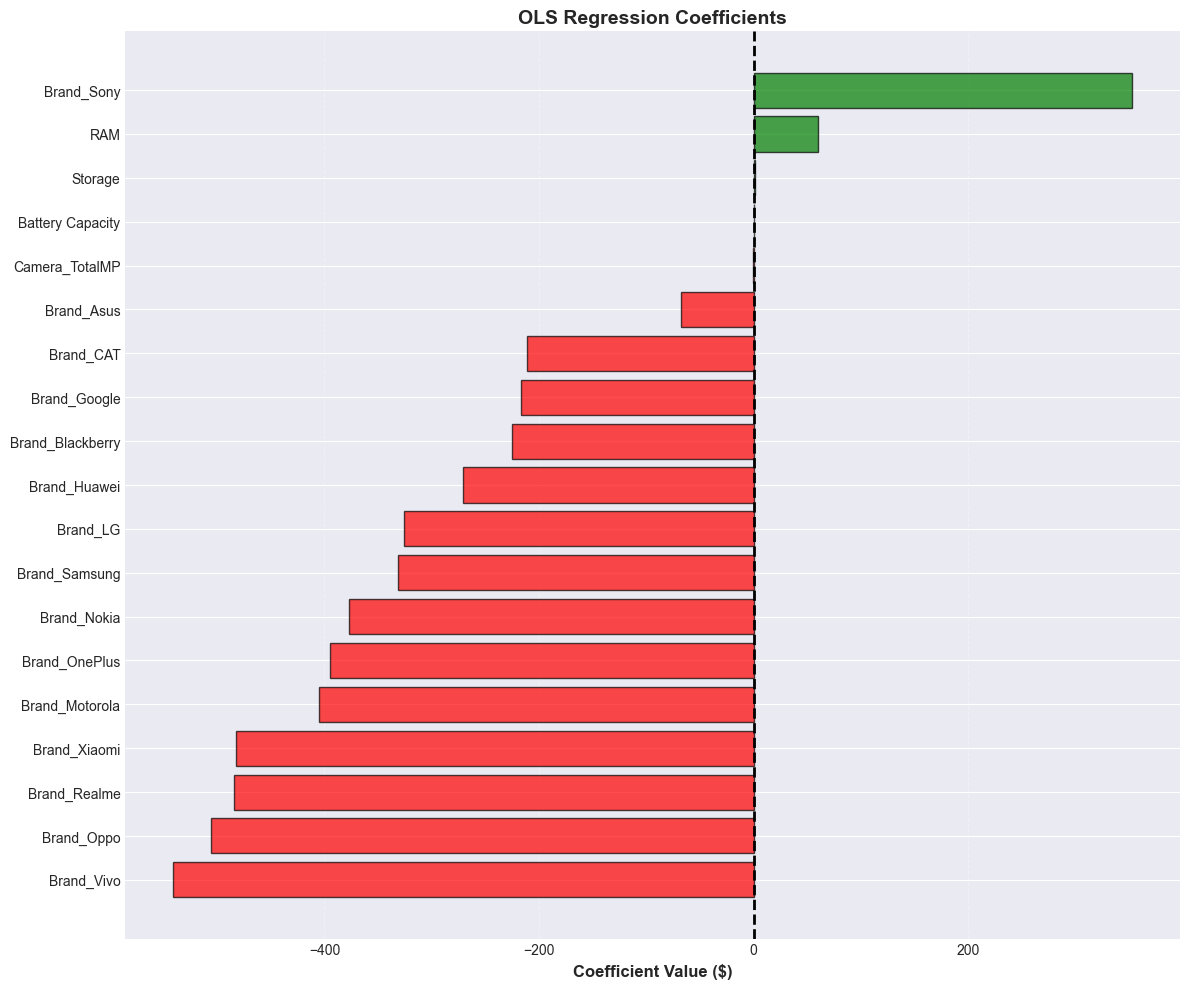

In [17]:
# Visualize all coefficients
plt.figure(figsize=(12, 10))
plt.barh(coef.index, coef.values, 
         color=['green' if v > 0 else 'red' for v in coef.values],
         alpha=0.7, edgecolor='black')
plt.xlabel("Coefficient Value ($)", fontsize=12, fontweight='bold')
plt.title("OLS Regression Coefficients", fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

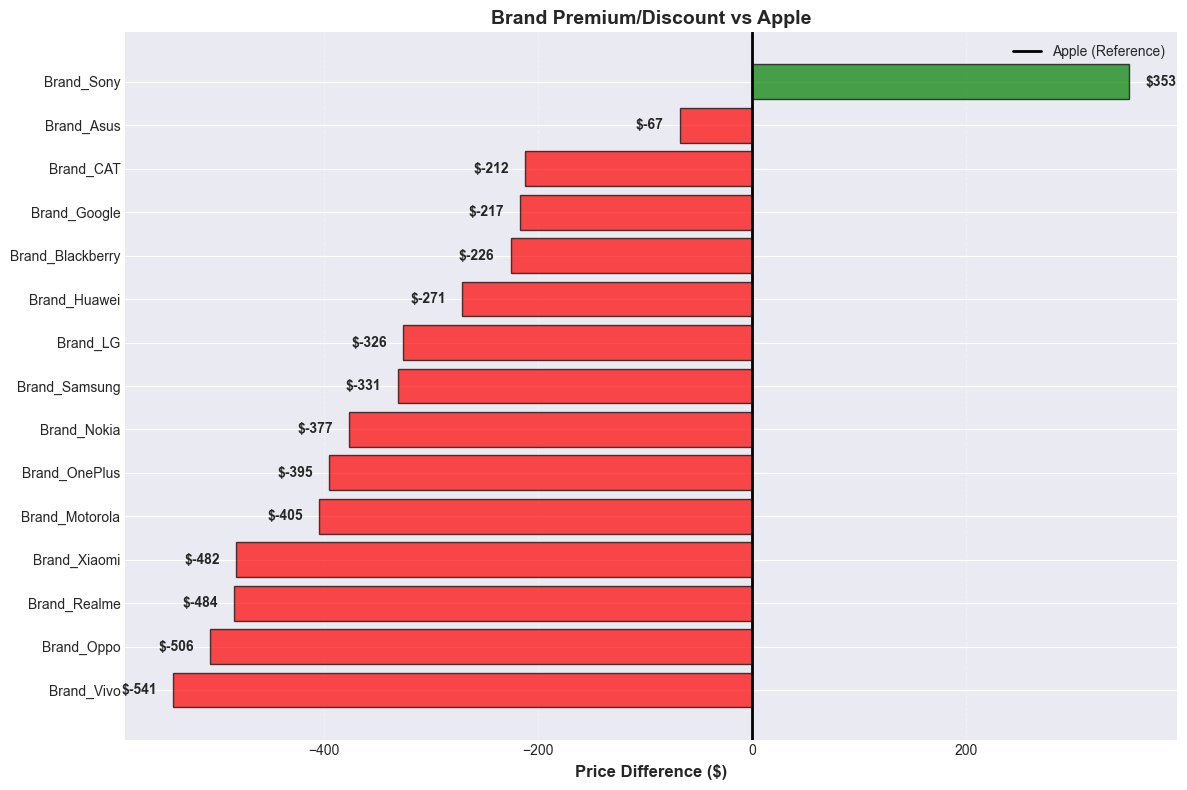

In [18]:
# Plot brand premiums separately
brand_coef = coef[coef.index.str.startswith("Brand_")]

plt.figure(figsize=(12, 8))
colors = ['green' if v > 0 else 'red' for v in brand_coef.values]
bars = plt.barh(brand_coef.index, brand_coef.values, color=colors, 
                alpha=0.7, edgecolor='black')
plt.title("Brand Premium/Discount vs Apple", fontsize=14, fontweight='bold')
plt.xlabel("Price Difference ($)", fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=2, label='Apple (Reference)')

# Add value labels
for bar in bars:
    w = bar.get_width()
    ha = 'left' if w > 0 else 'right'
    offset = 15 if w > 0 else -15
    plt.text(w + offset, bar.get_y() + bar.get_height()/2,
             f"${w:.0f}", va='center', ha=ha, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

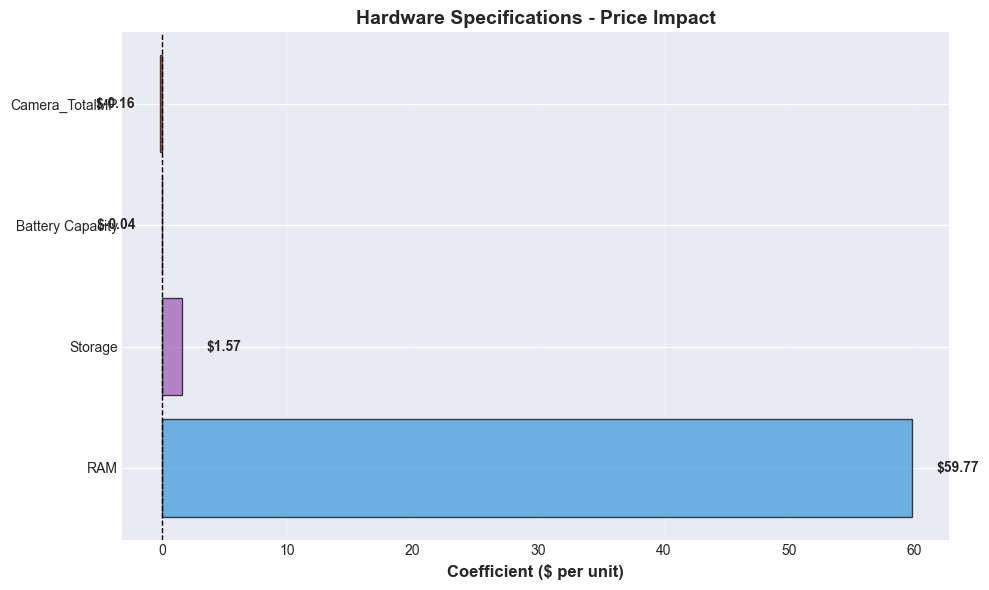

In [19]:
# Plot hardware coefficients
hardware = coef[features]

plt.figure(figsize=(10, 6))
colors_hw = ['#3498db', '#9b59b6', '#e67e22', '#e74c3c']
bars = plt.barh(hardware.index, hardware.values, color=colors_hw, 
                edgecolor='black', alpha=0.7)
plt.title("Hardware Specifications - Price Impact", fontsize=14, fontweight='bold')
plt.xlabel("Coefficient ($ per unit)", fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

for bar in bars:
    width = bar.get_width()
    ha = 'left' if width > 0 else 'right'
    offset = 2 if width > 0 else -2
    plt.text(width + offset, bar.get_y() + bar.get_height()/2,
             f"${width:.2f}", va='center', ha=ha, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 🔬 Section 7: Model Diagnostics

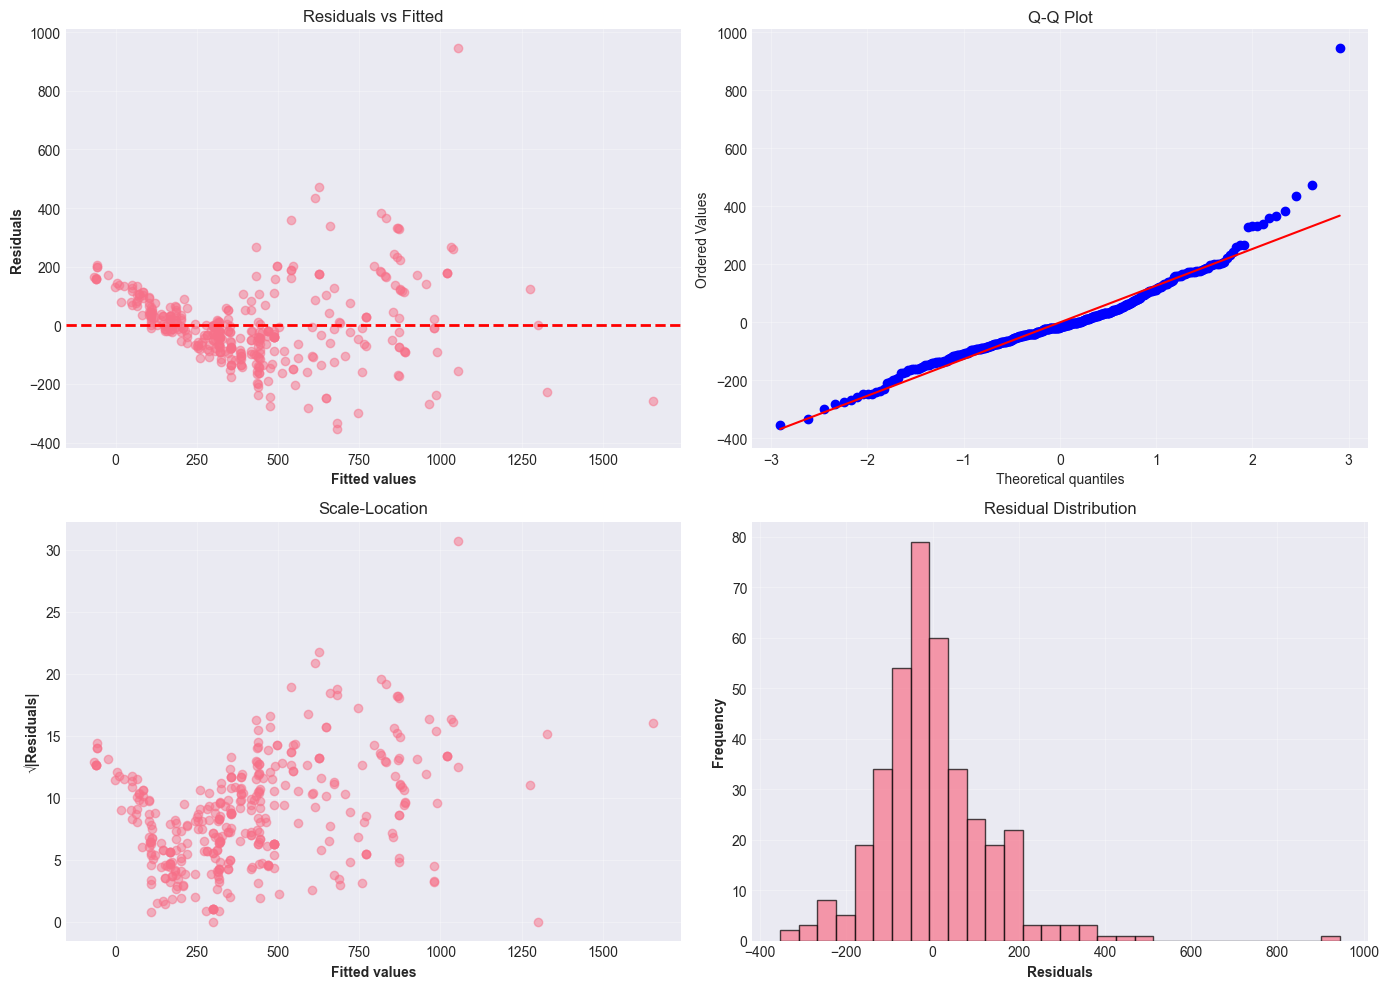

In [20]:
# Check model assumptions
residuals = model.resid
fitted_values = model.fittedvalues

# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted_values, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted values', fontweight='bold')
axes[0, 0].set_ylabel('Residuals', fontweight='bold')
axes[0, 0].set_title('Residuals vs Fitted')
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Scale-Location
axes[1, 0].scatter(fitted_values, np.sqrt(np.abs(residuals)), alpha=0.5)
axes[1, 0].set_xlabel('Fitted values', fontweight='bold')
axes[1, 0].set_ylabel('√|Residuals|', fontweight='bold')
axes[1, 0].set_title('Scale-Location')
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals histogram
axes[1, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Residuals', fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontweight='bold')
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Normality test
jb_stat, jb_p = jarque_bera(residuals)
print(f"Jarque-Bera Test for Normality:")
print(f"   Statistic: {jb_stat:.2f}")
print(f"   P-value: {jb_p:.6f}")

if jb_p < 0.05:
    print("   ⚠️ Residuals are NOT normally distributed")
    print("   💡 Consider log transformation of Price for better results")
else:
    print("   ✅ Residuals are normally distributed")

Jarque-Bera Test for Normality:
   Statistic: 959.13
   P-value: 0.000000
   ⚠️ Residuals are NOT normally distributed
   💡 Consider log transformation of Price for better results


## 🗺️ Section 8: Correspondence Analysis

In [22]:
# Create price categories
data['Price_Category'] = pd.qcut(data['Price'], q=4, 
                                 labels=['Low', 'Medium', 'High', 'Premium'])

# Create contingency table
table = pd.crosstab(data['Brand'], data['Price_Category'])
print("Contingency Table (Brand vs Price Category):")
print(table)

Contingency Table (Brand vs Price Category):
Price_Category  Low  Medium  High  Premium
Brand                                     
Apple             0       0     5       21
Asus              0       0     0        4
Blackberry        0       0     2        1
CAT               0       1     0        0
Google            0       0     1        4
Huawei            1       0     3        8
LG                0       0     2        1
Motorola          8      10     3        1
Nokia            15       5     3        1
OnePlus           0       1     4        9
Oppo             13      16    13       11
Realme           26      12     5        0
Samsung          15      18    21       19
Sony              0       0     0        1
Vivo              9      13     8        3
Xiaomi           23      20    14        5


In [23]:
# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(table)
print(f"Chi-Square Test:")
print(f"   Chi-square statistic: {chi2:.2f}")
print(f"   P-value: {p_value:.6f}")
print(f"   Degrees of freedom: {dof}")

if p_value < 0.05:
    print("   ✅ Significant association between Brand and Price Category")
else:
    print("   ❌ No significant association")

Chi-Square Test:
   Chi-square statistic: 187.03
   P-value: 0.000000
   Degrees of freedom: 45
   ✅ Significant association between Brand and Price Category


In [24]:
# Perform Correspondence Analysis
if PRINCE_AVAILABLE:
    print("Performing Correspondence Analysis with prince...")
    ca = prince.CA(n_components=2)
    ca = ca.fit(table)
    row_coords = ca.row_coordinates(table)
    col_coords = ca.column_coordinates(table)
    method_used = "Prince CA"
else:
    print("Using simplified visualization (prince not available)...")
    # Simple approach: position brands by their price distribution
    price_values = {'Low': 0, 'Medium': 1, 'High': 2, 'Premium': 3}
    
    row_coords_data = []
    for brand in table.index:
        weighted_pos = sum(table.loc[brand, cat] * price_values[cat] 
                          for cat in table.columns) / table.loc[brand].sum()
        volume = table.loc[brand].sum()
        row_coords_data.append([weighted_pos, np.log(volume + 1)])
    
    row_coords = pd.DataFrame(row_coords_data, index=table.index, columns=[0, 1])
    
    col_coords_data = [[price_values[cat], 0] for cat in table.columns]
    col_coords = pd.DataFrame(col_coords_data, index=table.columns, columns=[0, 1])
    method_used = "Simplified Visualization"

print(f"✅ Using method: {method_used}")

Performing Correspondence Analysis with prince...
✅ Using method: Prince CA


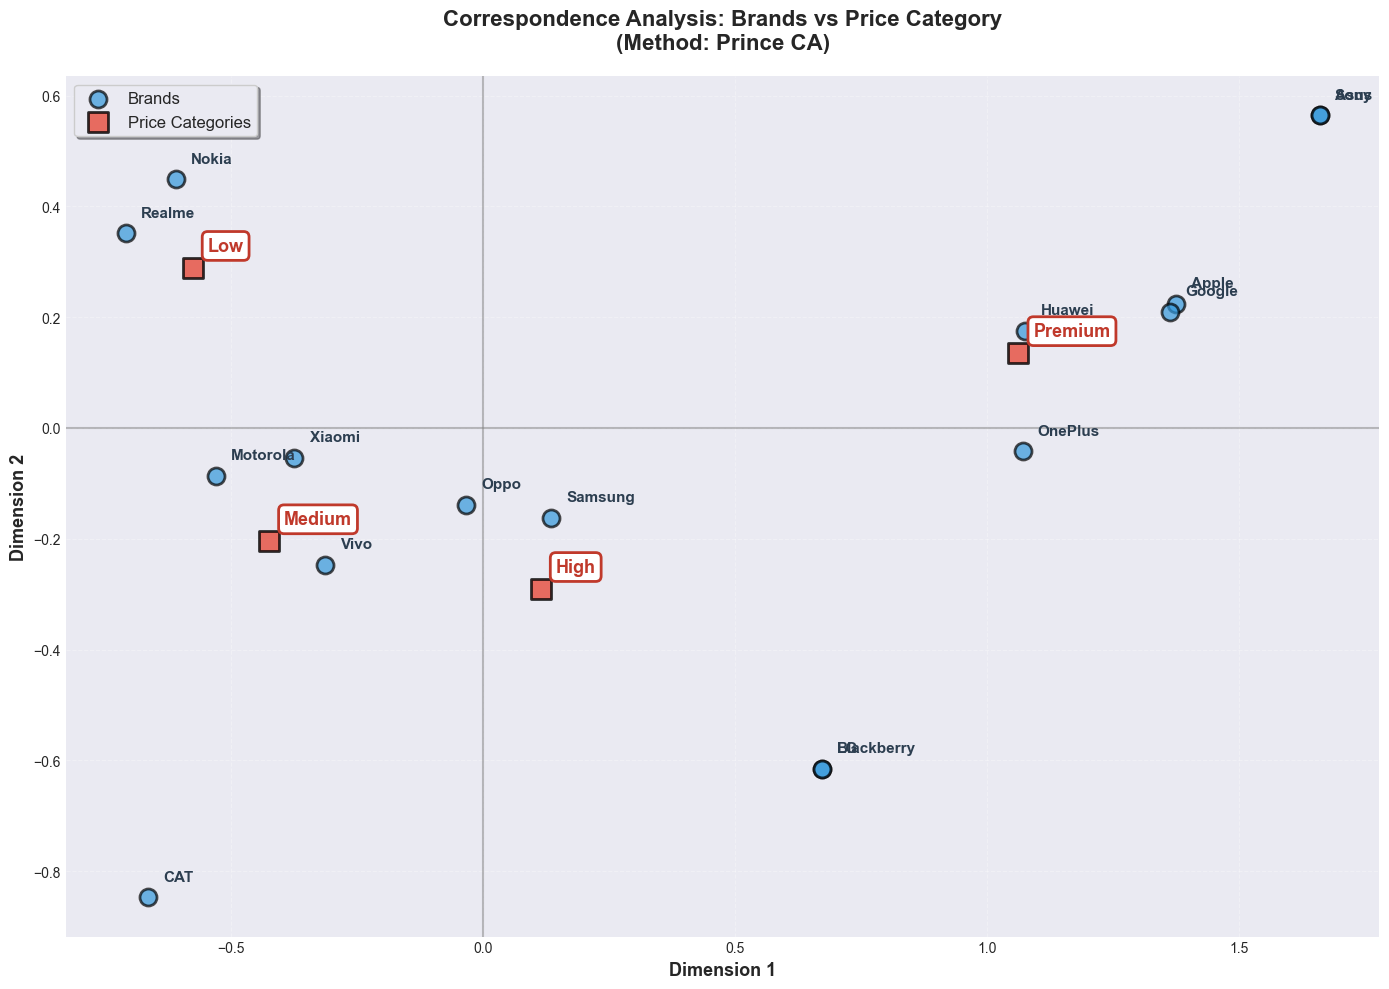

In [25]:
# Visualize Correspondence Analysis
plt.figure(figsize=(14, 10))

# Plot brands
plt.scatter(row_coords[0], row_coords[1], color='#3498db', s=150, 
           alpha=0.7, edgecolors='black', linewidths=2, label='Brands', zorder=3)

for i, txt in enumerate(row_coords.index):
    plt.text(row_coords.iloc[i, 0] + 0.03, row_coords.iloc[i, 1] + 0.03, 
             txt, fontsize=11, fontweight='bold', color='#2c3e50')

# Plot price categories
plt.scatter(col_coords[0], col_coords[1], color='#e74c3c', s=200, 
           marker='s', alpha=0.8, edgecolors='black', linewidths=2, 
           label='Price Categories', zorder=3)

for i, txt in enumerate(col_coords.index):
    plt.text(col_coords.iloc[i, 0] + 0.03, col_coords.iloc[i, 1] + 0.03, 
             txt, fontsize=13, fontweight='bold', color='#c0392b',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                      edgecolor='#c0392b', linewidth=2))

plt.title(f"Correspondence Analysis: Brands vs Price Category\n(Method: {method_used})", 
         fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Dimension 1", fontsize=13, fontweight='bold')
plt.ylabel("Dimension 2", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.axhline(0, color='gray', linewidth=1.5, alpha=0.5)
plt.axvline(0, color='gray', linewidth=1.5, alpha=0.5)
plt.legend(fontsize=12, loc='best', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

## 🎯 Section 9: Outlier Detection

In [26]:
# Check if outliers already detected
if 'Outlier' in data.columns:
    print("✅ Outliers already detected in dataset")
    outliers = data[data['Outlier'] == True]
else:
    print("Performing outlier detection with Isolation Forest...")
    
    # Prepare features
    outlier_features = ['Storage', 'RAM', 'Battery Capacity', 'Price']
    X_outlier = data[outlier_features].apply(pd.to_numeric, errors='coerce')
    
    # Fit Isolation Forest
    iso = IsolationForest(contamination=0.05, random_state=42)
    data['Outlier_flag'] = iso.fit_predict(X_outlier)
    data['Outlier'] = data['Outlier_flag'] == -1
    
    outliers = data[data['Outlier'] == True]
    print(f"✅ Detected {len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%)")

# Display statistics
print(f"\nOutlier Statistics:")
print(f"   Total outliers: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
print(f"\n   Outliers by brand:")
print(outliers['Brand'].value_counts())

Performing outlier detection with Isolation Forest...
✅ Detected 19 outliers (5.0%)

Outlier Statistics:
   Total outliers: 19 (5.01%)

   Outliers by brand:
Brand
Apple      8
Samsung    5
Nokia      2
Oppo       2
Asus       1
Huawei     1
Name: count, dtype: int64


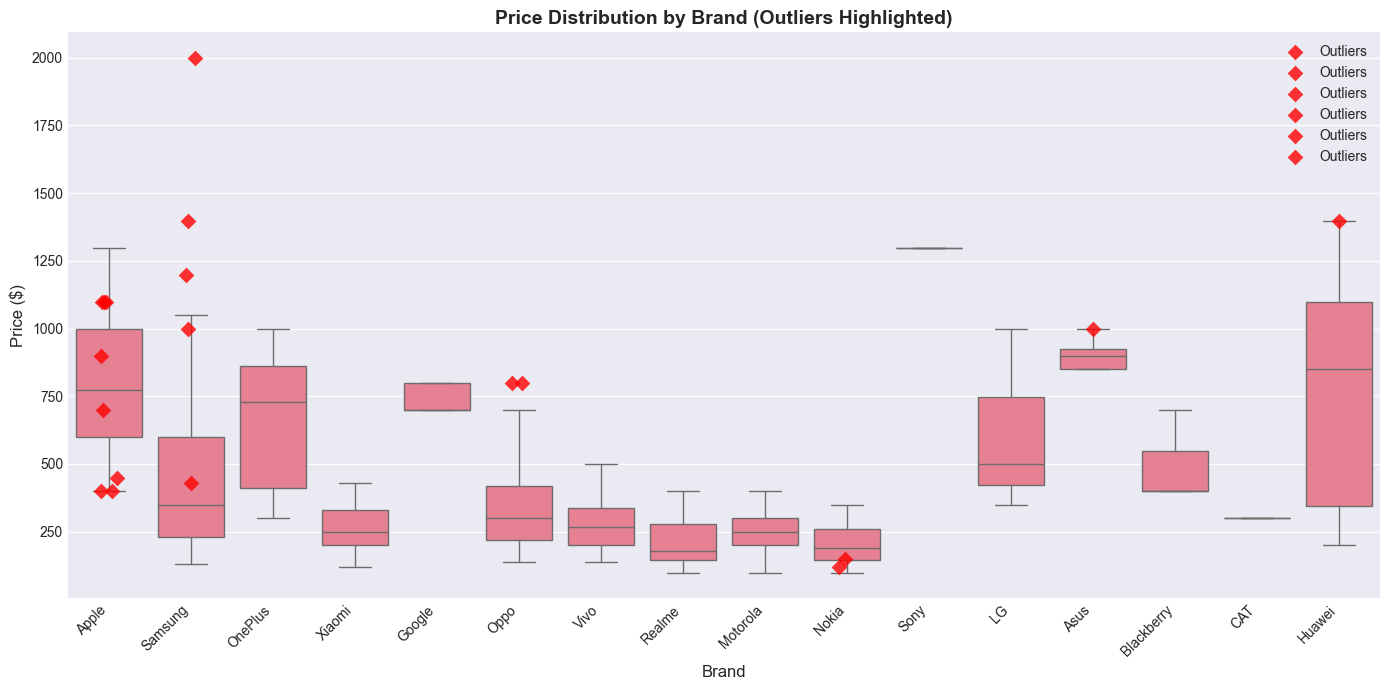

In [27]:
# Visualize outliers
plt.figure(figsize=(14, 7))
sns.boxplot(x='Brand', y='Price', data=data, showfliers=False)
sns.stripplot(x='Brand', y='Price', data=data[data['Outlier']], 
              color='red', size=8, marker='D', label='Outliers', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution by Brand (Outliers Highlighted)', 
         fontsize=14, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12)
plt.xlabel('Brand', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 💰 Section 10: Value-for-Money Analysis

In [28]:
# Create value score if not present
if 'Value_Score' not in data.columns:
    print("Computing Value Score...")
    
    value_features = ['RAM', 'Storage', 'Battery Capacity']
    scaler = MinMaxScaler()
    data_norm = scaler.fit_transform(data[value_features])
    data_norm = pd.DataFrame(data_norm, columns=[f + '_norm' for f in value_features])
    
    for col in data_norm.columns:
        data[col] = data_norm[col]
    
    data['Value_Score'] = (
        data['RAM_norm'] + 
        data['Storage_norm'] + 
        data['Battery Capacity_norm']
    ) / data['Price']
    
    print("✅ Value Score computed")

# Analyze budget phones
budget_phones = data[data['Price'] <= 400].copy()
print(f"\nBudget Phones (Price ≤ $400): {len(budget_phones)} phones")

# Top 10 value phones
best_budget = budget_phones.sort_values('Value_Score', ascending=False).head(10)
print("\nTop 10 Best Value-for-Money Phones:")
print(best_budget[['Brand', 'Model', 'Price', 'RAM', 'Storage', 
                   'Battery Capacity', 'Value_Score']].to_string(index=False))

Computing Value Score...
✅ Value Score computed

Budget Phones (Price ≤ $400): 260 phones

Top 10 Best Value-for-Money Phones:
   Brand              Model  Price  RAM  Storage  Battery Capacity  Value_Score
  Xiaomi            Poco M3  149.0    4      128              6000     0.007717
  Realme               C25s  149.0    4      128              6000     0.007717
  Realme               C25s  159.0    4      128              6000     0.007231
  Realme               C25s  159.0    4      128              6000     0.007231
  Xiaomi     Redmi 10 Prime  179.0    6      128              6000     0.007221
  Realme               C21Y  119.0    4       64              5000     0.006919
   Nokia           C20 Plus   99.0    3       32              4950     0.006824
  Realme          Narzo 50A  149.0    4       64              6000     0.006822
Motorola Moto G9 Power Lite  149.0    4       64              6000     0.006822
  Realme               C25s  169.0    4      128              6000     0.

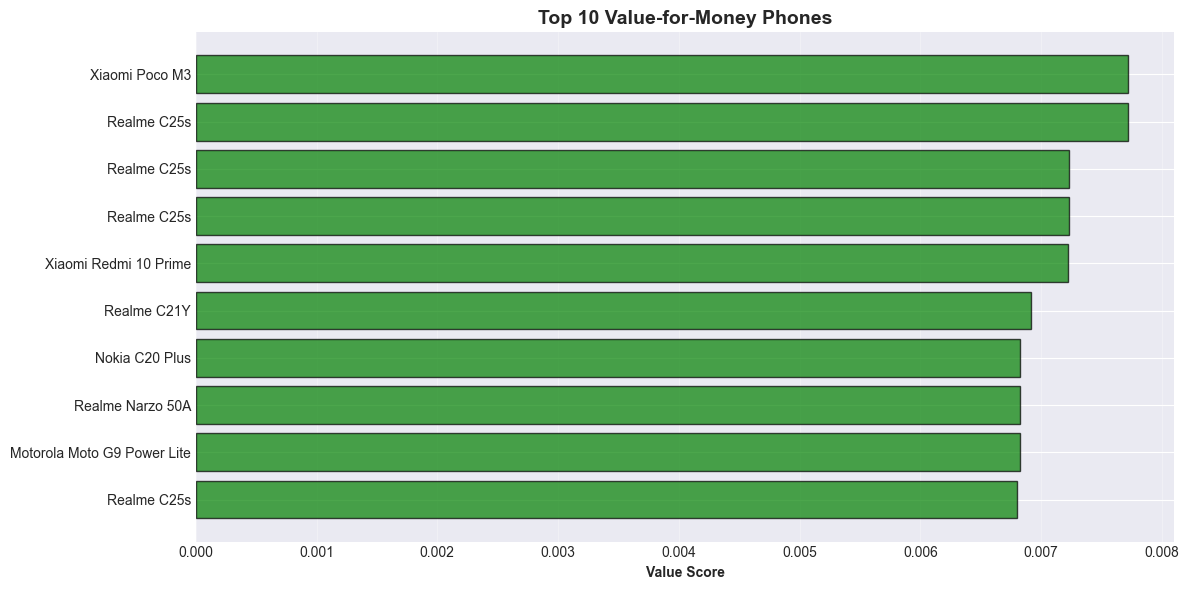

In [29]:
# Visualize top value phones
plt.figure(figsize=(12, 6))
top10 = best_budget.head(10)
x_pos = range(len(top10))
plt.barh(x_pos, top10['Value_Score'], color='green', alpha=0.7, edgecolor='black')
plt.yticks(x_pos, [f"{row['Brand']} {row['Model']}" 
                   for _, row in top10.iterrows()])
plt.xlabel('Value Score', fontweight='bold')
plt.title('Top 10 Value-for-Money Phones', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 📋 Section 11: Final Summary

In [35]:
# Generate final summary
print("="*80)
print("ANALYSIS COMPLETE - FINAL SUMMARY")
print("="*80)

print(f"\n✅ Dataset: {len(data)} mobile phones analyzed")
print(f"✅ Brands: {data['Brand'].nunique()} unique brands")
print(f"✅ Price range: ${data['Price'].min():.0f} - ${data['Price'].max():.0f}")

print(f"\n📈 KEY FINDINGS:")
print(f"\n1. OLS REGRESSION:")
print(f"   • R² = {model.rsquared:.4f} ({model.rsquared*100:.1f}% of variance explained)")
print(f"   • Adj. R² = {model.rsquared_adj:.4f}")
print(f"   • Most important factor: RAM (+${model.params['RAM']:.2f} per GB)")
print(f"   • Apple is reference brand (constant = ${model.params['const']:.2f})")

brand_coef_summary = coef[coef.index.str.startswith("Brand_")].sort_values(ascending=False)
print(f"\n2. BRAND EFFECTS:")
print(f"   • Most expensive vs Apple: {brand_coef_summary.index[0].replace('Brand_', '')} (+${brand_coef_summary.iloc[0]:.2f})")
print(f"   • Most discounted vs Apple: {brand_coef_summary.index[-1].replace('Brand_', '')} (${brand_coef_summary.iloc[-1]:.2f})")

print(f"\n3. OUTLIERS:")
print(f"   • Detected: {len(outliers)} phones ({len(outliers)/len(data)*100:.1f}%)")
if len(outliers) > 0:
    print(f"   • Most affected brand: {outliers['Brand'].value_counts().index[0]}")

print(f"\n4. BEST VALUE:")
print(f"   • Top budget phone: {best_budget.iloc[0]['Brand']} {best_budget.iloc[0]['Model']}")
print(f"   • Price: ${best_budget.iloc[0]['Price']:.0f}")
print(f"   • Value Score: {best_budget.iloc[0]['Value_Score']:.6f}")



ANALYSIS COMPLETE - FINAL SUMMARY

✅ Dataset: 379 mobile phones analyzed
✅ Brands: 16 unique brands
✅ Price range: $99 - $1999

📈 KEY FINDINGS:

1. OLS REGRESSION:
   • R² = 0.8157 (81.6% of variance explained)
   • Adj. R² = 0.8059
   • Most important factor: RAM (+$59.77 per GB)
   • Apple is reference brand (constant = $434.35)

2. BRAND EFFECTS:
   • Most expensive vs Apple: Sony (+$352.74)
   • Most discounted vs Apple: Vivo ($-540.92)

3. OUTLIERS:
   • Detected: 19 phones (5.0%)
   • Most affected brand: Apple

4. BEST VALUE:
   • Top budget phone: Xiaomi Poco M3
   • Price: $149
   • Value Score: 0.007717


In [39]:
# thresholds based on your dataset distribution
price_high = data['Price'].quantile(0.75)
ram_low    = data['RAM'].quantile(0.25)
storage_low = data['Storage'].quantile(0.25)
battery_low = data['Battery Capacity'].quantile(0.25)

price_high, ram_low, storage_low, battery_low

(np.float64(499.0), np.float64(4.0), np.float64(64.0), np.float64(4300.0))

In [40]:
def categorize_outlier(row):
    categories = []

    if row['Price'] > price_high:
        categories.append('High Price')

    if row['RAM'] < ram_low:
        categories.append('Low RAM')

    if row['Storage'] < storage_low:
        categories.append('Low Storage')

    if row['Battery Capacity'] < battery_low:
        categories.append('Low Battery')

    # If no category matched
    if len(categories) == 0:
        categories.append('Unusual Combination')

    return ', '.join(categories)

In [41]:
outliers = data[data['Outlier'] == True].copy()

outliers['Outlier_Category'] = outliers.apply(categorize_outlier, axis=1)

outliers[['Brand', 'Model', 'Price', 'RAM', 'Storage',
          'Battery Capacity', 'Outlier_Category']]

print("\n" + "="*80)
print("✨ ANALYSIS COMPLETE!")
print("="*80)


✨ ANALYSIS COMPLETE!


(np.float64(499.0), np.float64(4.0), np.float64(64.0), np.float64(4300.0))